# Nanoparticle segmentation
Plots for nanoparticle segmentation

In [1]:
# Imports
from pathlib import Path
import warnings
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import zarr
from skimage.measure import find_contours
from skimage.exposure import rescale_intensity

with warnings.catch_warnings():
    warnings.filterwarnings("ignore", category=UserWarning)
    from sphero_vem.segmentation.np import NanoparticleSegmentation

plt.rcParams["font.family"] = "Arial"

In [2]:
# Save dirs
save_root = Path("../data/figures/paper/segmentation")
save_root.mkdir(exist_ok=True, parents=True)

## Probability distributions

### Decomposition

In [3]:
# Load models
model_root = Path("../data/models/nps/nps-20251121_175218")
params = np.load(model_root / "model_params.npz")

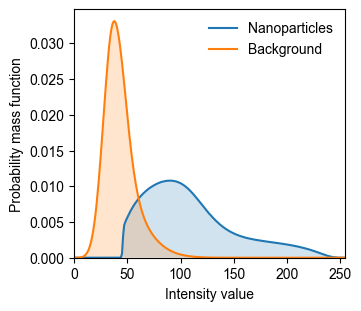

In [4]:
fig, ax = plt.subplots(layout="constrained", figsize=(3.5, 3))

alpha = 0.2

ax.plot(params["p_np"], label="Nanoparticles")
ax.fill(params["p_np"], alpha=alpha)

ax.plot(params["p_bg"], label="Background")
ax.fill(params["p_bg"], alpha=alpha)

ax.set(
    xlim=(0, 255),
    ylim=(0, max(params["p_np"].max(), params["p_bg"].max()) * 1.05),
    xlabel="Intensity value",
    ylabel="Probability mass function",
)
ax.legend(frameon=False)
fig.savefig(save_root / "np-segmentation-decomposition.pdf")

### Posterior
Select one image and calculate posterior probability

In [5]:
# Load model
model_root = Path("../data/models/nps/nps-20251121_175218")
segmentation_model = NanoparticleSegmentation.load(model_root)

In [6]:
# Load images
data_root = Path("../data/processed/segmented/Au_01-vol_01.zarr")
image_zarr = zarr.open_array(data_root / "images/50-10-10", mode="r")

In [7]:
# Calculate posterior
image_idx = 564

image = image_zarr[image_idx]
posterior_map, posterior_dist = segmentation_model._posterior_image(image)

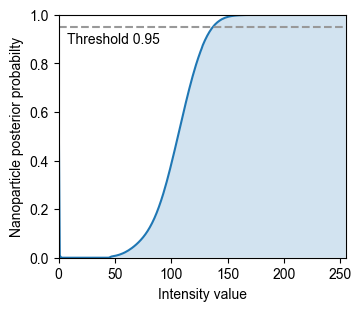

In [8]:
fig, ax = plt.subplots(layout="constrained", figsize=(3.5, 3))

alpha = 0.2

x = np.arange(len(posterior_dist))

ax.plot(x, posterior_dist)
ax.fill_between(x, y1=posterior_dist, y2=0, alpha=alpha)
ax.set(
    xlim=(0, 255),
    ylim=[0, 1],
    xlabel="Intensity value",
    ylabel="Nanoparticle posterior probabilty",
)

posterior_th = 0.95
ax.axhline(posterior_th, c="0.6", ls="--")
ax.text(
    x=0.03,
    y=0.93,
    s=f"Threshold {posterior_th}",
    transform=ax.transAxes,
    verticalalignment="top",
    horizontalalignment="left",
)
fig.savefig(save_root / "np-segmentation-posterior-dist.pdf")

### Posterior maps

In [9]:
# Functions
def plot_cbar(
    ax, image, cmap="coolwarm", colorbar_width="5%", colorbar_pad=0.1, **cbar_kwargs
):
    """Plot image with colorbar with proper sizing"""

    # Create discrete colormap
    im = ax.imshow(image, cmap=cmap, vmax=1, vmin=0)

    # Create colorbar axis with controlled size
    cax = inset_axes(
        ax,
        width=colorbar_width,
        height="100%",
        loc="center left",
        bbox_to_anchor=(1 + colorbar_pad, 0.0, 1, 1),
        bbox_transform=ax.transAxes,
        borderpad=0,
    )

    cbar = plt.colorbar(im, cax=cax, extend="neither", **cbar_kwargs)
    for spine in cbar.ax.spines.values():
        spine.set_visible(False)

    return cax

In [10]:
# Load data
data_root = Path("../data/processed/segmented/Au_01-vol_01.zarr")
spacing_dir = "50-50-50"

image_zarr = zarr.open_array(data_root / f"images/{spacing_dir}", mode="r")
posterior_zarr = zarr.open_array(
    data_root / f"labels/nps/posterior/{spacing_dir}", mode="r"
)
masks_zarr = zarr.open_array(data_root / f"labels/nps/masks/{spacing_dir}", mode="r")

In [11]:
# Define spatial parameters
img_idx = 564

top_corner = [350, 340]
width = 500
crop_slice = (
    img_idx,
    slice(top_corner[0], top_corner[0] + width),
    slice(top_corner[1], top_corner[1] + width),
)

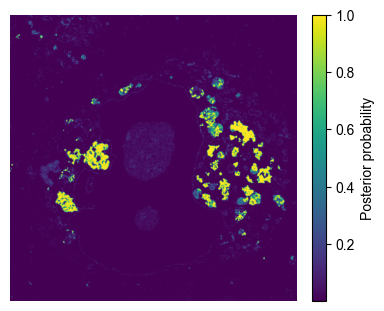

In [12]:
# Plot posterior
fig, ax = plt.subplots(layout="constrained", figsize=(4, 3))
cmap = "viridis"
im = ax.imshow(posterior_zarr[crop_slice], cmap=cmap)
cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Posterior probability")
# plot_cbar(ax, posterior_zarr[crop_slice], cmap=cmap, colorbar_pad=0.02, label="Posterior probability")
ax.set_axis_off()
fig.savefig(
    save_root / f"np-segmentation-posterior-map-image_{img_idx}.pdf",
    bbox_inches="tight",
    pad_inches=0.01,
    dpi=300,
)

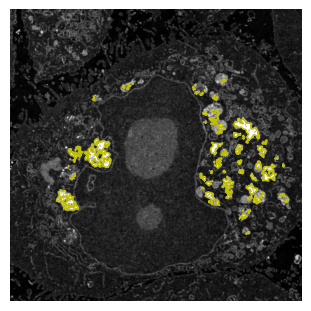

In [13]:
# Plot masks
contours = find_contours(masks_zarr[crop_slice])

image_crop = image_zarr[crop_slice]
image_rescaled = rescale_intensity(
    image_crop, in_range=tuple(np.quantile(image_crop, [0.01, 0.99]))
)

fig, ax = plt.subplots(layout="constrained", figsize=(3, 3))
cmap = "gray"
ax.imshow(image_rescaled, cmap=cmap)
ax.set_axis_off()

for contour in contours:
    ax.plot(contour[:, 1], contour[:, 0], color="y", lw=1)

fig.savefig(
    save_root / f"np-segmentation-masks-image_{img_idx}.pdf",
    bbox_inches="tight",
    pad_inches=0.0,
    dpi=300,
)